<a href="https://colab.research.google.com/github/jhlopesalves/data-science-notebooks/blob/main/Python/projects/magic_gamma/magic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Donated by:
P. Savicky
Institute of Computer Science, AS of CR
Czech Republic
savicky '@' cs.cas.cz

In [2]:
cols = [
	"fLength",
	"fWidth",
	"fSize",
	"fConc",
	"fConc1",
	"fAsym",
	"fM3Long",
	"fM3Trans",
	"fAlpha",
	"fDist",
	"class",
]
url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/magic_gamma/data/magic04.data"
df = pd.read_csv(url, names=cols, usecols=lambda col: not col.startswith("Unnamed"))
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
# Binary encode: gamma ('g') → 1, hadron ('h') → 0, as int8
df["class"] = (df["class"].str.lower() == "g").astype("int8")

# Basic sanity check
class_counts = df["class"].value_counts().sort_index()
print({0: int(class_counts.get(0, 0)), 1: int(class_counts.get(1, 1))})

{0: 6688, 1: 12332}


In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


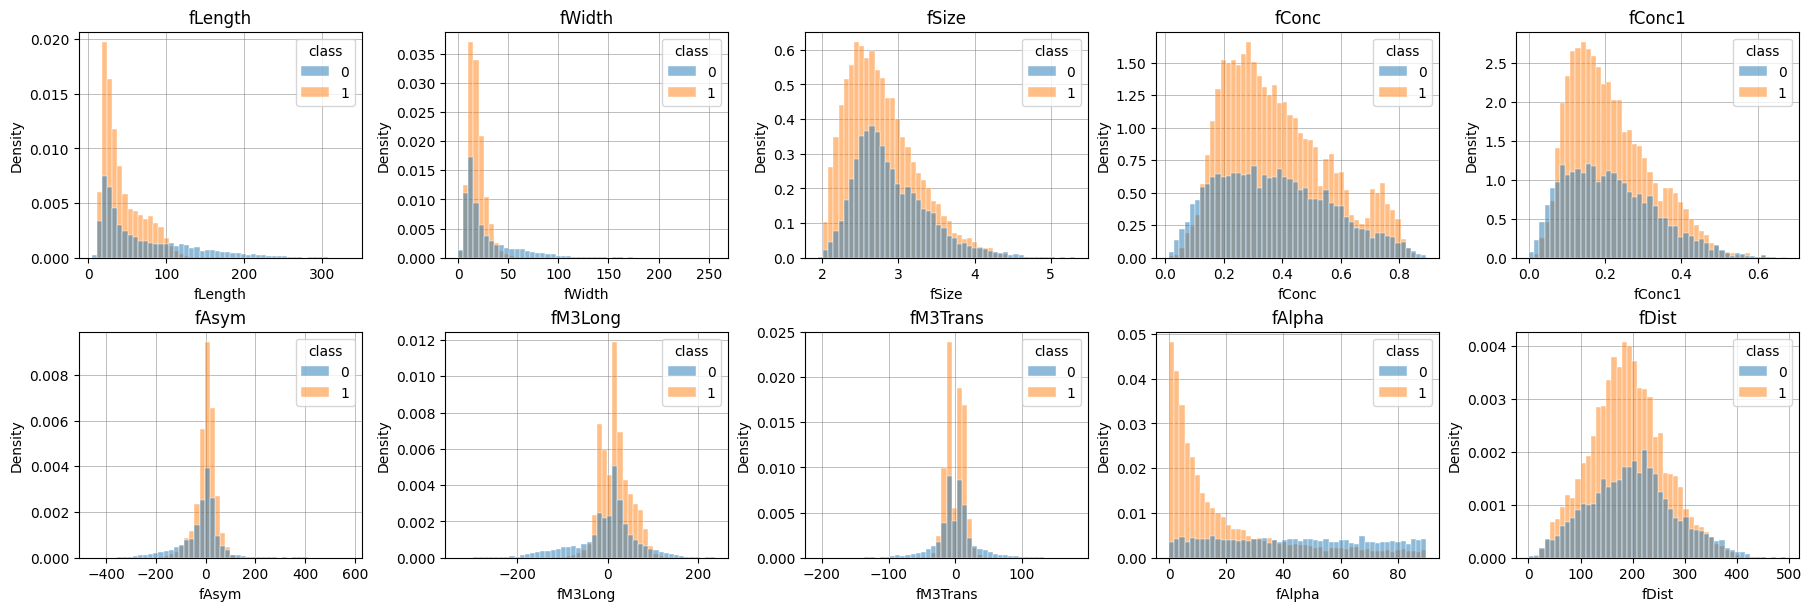

In [5]:
feature_names = cols[:-1]
num_features = len(feature_names)

# Grid size: 2 rows × 5 cols for 10 features
fig, axes = plt.subplots(2, 5, figsize=(18, 6), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
	sns.histplot(
		data=df,
		x=feature,
		hue="class",
		hue_order=[0, 1],
		stat="density",
		bins=50,
		alpha=0.5,
		edgecolor="white",
		linewidth=0.3,
		ax=axis,
	)
	axis.set_title(feature)
	axis.set_xlabel(feature)
	axis.set_ylabel("Density")
	axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	axis.set_axisbelow(True)

# Single, consistent legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["hadron (0)", "gamma (1)"], loc="upper right", frameon=False)
plt.show()

# Train, validation, test datasets

In [6]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def scale_dataset(dataframe, oversample=False):
	X = dataframe.drop("class", axis=1).copy()
	y = dataframe["class"].copy()

	# First: pull out 20% test
	X_train_valid, X_test, y_train_valid, y_test = train_test_split(
		X, y, test_size=0.20, stratify=y, random_state=42
	)

	# Second: from the remaining 80%, take 25% for validation -> 0.25 * 0.80 = 0.20 overall
	X_train, X_valid, y_train, y_valid = train_test_split(
		X_train_valid,
		y_train_valid,
		test_size=0.25,
		stratify=y_train_valid,
		random_state=42,
	)

	scaler = StandardScaler()
	X_train = scaler.fit_transform(X_train)
	X_valid = scaler.transform(X_valid)
	X_test = scaler.transform(X_test)

	if oversample:
		ros = RandomOverSampler()
		X_train, y_train = ros.fit_resample(X_train, y_train)

	train = np.hstack((X_train, np.reshape(y_train, (-1, 1))))
	valid = np.hstack((X_valid, np.reshape(y_valid, (-1, 1))))
	test = np.hstack((X_test, np.reshape(y_test, (-1, 1))))

	return (train, X_train, y_train), (valid, X_valid, y_valid), (test, X_test, y_test)

In [7]:
(train, X_train, y_train), (valid, X_valid, y_valid), (test, X_test, y_test) = (
	scale_dataset(df, oversample=True)
)

## K-Nearest Neighbors (KNN) Classifier

K-Nearest Neighbors is a simple, instance-based learning algorithm that classifies data points based on the majority class among their k nearest neighbors.

### Distance Metrics

The algorithm uses distance metrics to find the nearest neighbors. Common distance metrics include:

**Euclidean Distance:**
$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

**Manhattan Distance:**
$$d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^n |x_i - y_i|$$

**Minkowski Distance (generalization):**
$$d(\mathbf{x}, \mathbf{y}) = \left(\sum_{i=1}^n |x_i - y_i|^p\right)^{1/p}$$

### Classification Rule

For a test instance $\mathbf{x}$, the predicted class $\hat{y}$ is determined by:

$$\hat{y} = \arg\max_{c} \sum_{(\mathbf{x}_i, y_i) \in N_k(\mathbf{x})} \mathbb{I}(y_i = c)$$

Where:
- $N_k(\mathbf{x})$ is the set of k nearest neighbors to $\mathbf{x}$
- $\mathbb{I}(\cdot)$ is the indicator function (1 if true, 0 otherwise)
- $c$ represents each possible class

### Weighted KNN

In weighted KNN, closer neighbors have more influence:

$$\hat{y} = \arg\max_{c} \sum_{(\mathbf{x}_i, y_i) \in N_k(\mathbf{x})} w_i \cdot \mathbb{I}(y_i = c)$$

Where the weight $w_i$ is typically inversely proportional to the distance:

$$w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)} \quad \text{or} \quad w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)^2}$$

### Algorithm Steps

1. **Compute distances** between the test instance and all training instances
2. **Select k nearest neighbors** based on the smallest distances
3. **Vote for the class** by majority among the k neighbors
4. **Return the predicted class** with the highest vote count

### Time Complexity

- **Training:** $O(1)$ - KNN is a lazy learner, no explicit training phase
- **Prediction:** $O(n \cdot d)$ per test instance, where $n$ is the number of training instances and $d$ is the number of features

In [8]:
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [9]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [10]:
y_pred = knn_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      1338
           1       0.85      0.84      0.85      2466

    accuracy                           0.80      3804
   macro avg       0.78      0.78      0.78      3804
weighted avg       0.80      0.80      0.80      3804



## Naive Bayes Classifier

Naive Bayes classifiers are based on Bayes' theorem with the "naive" assumption of conditional independence between every pair of features given the value of the class variable.

### Bayes' Theorem

$$P(y|X) = \frac{P(X|y)P(y)}{P(X)}$$

Where:
- $P(y|X)$ is the posterior probability of class $y$ given features $X$
- $P(X|y)$ is the likelihood of features $X$ given class $y$
- $P(y)$ is the prior probability of class $y$
- $P(X)$ is the evidence (probability of features $X$)

### Naive Assumption

The "naive" assumption states that features are conditionally independent given the class:

$$P(X|y) = P(x_1, x_2, \dots, x_n|y) = \prod_{i=1}^n P(x_i|y)$$

### Classification Rule

For a given instance with features $X = (x_1, x_2, \dots, x_n)$, we predict the class that maximizes the posterior probability:

$$\hat{y} = \arg\max_y P(y) \prod_{i=1}^n P(x_i|y)$$

### Gaussian Naive Bayes

For continuous features, we assume each feature follows a Gaussian distribution:

$$P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

Where:
- $\mu_y$ is the mean of feature $x_i$ for class $y$
- $\sigma_y^2$ is the variance of feature $x_i$ for class $y$

### Log Probabilities

In practice, we use log probabilities to avoid numerical underflow:

$$\log P(y|X) = \log P(y) + \sum_{i=1}^n \log P(x_i|y) - \log P(X)$$

Since $P(X)$ is constant for all classes, we can simplify to:

$$\hat{y} = \arg\max_y \left[\log P(y) + \sum_{i=1}^n \log P(x_i|y)\right]$$

In [11]:
from sklearn.naive_bayes import GaussianNB

In [12]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [13]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.41      0.51      1338
           1       0.74      0.89      0.81      2466

    accuracy                           0.72      3804
   macro avg       0.71      0.65      0.66      3804
weighted avg       0.72      0.72      0.70      3804



## Logistic Regression

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z$ is the linear combination of features:

$$z = \mathbf{w}^T \mathbf{x} + b = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

The probability that an instance $\mathbf{x}$ belongs to class 1 is:

$$P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

And the probability of class 0 is:

$$P(y=0|\mathbf{x}) = 1 - P(y=1|\mathbf{x})$$

### Cost Function

Logistic Regression uses the log loss (binary cross-entropy) as its cost function:

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Where:
- $m$ is the number of training examples
- $y^{(i)}$ is the true label for the $i$-th example
- $\hat{y}^{(i)} = \sigma(\mathbf{w}^T \mathbf{x}^{(i)} + b)$ is the predicted probability

### Decision Boundary

The model predicts class 1 if $P(y=1|\mathbf{x}) \geq 0.5$, which occurs when:

$$\mathbf{w}^T \mathbf{x} + b \geq 0$$

Otherwise, it predicts class 0.

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [16]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.71      0.69      1338
           1       0.84      0.82      0.83      2466

    accuracy                           0.78      3804
   macro avg       0.76      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



## Support-Vector Classification (SVC)

Support Vector Machines (SVM) for classification aim to find the optimal hyperplane that separates classes with the maximum margin. The objective function for a linear SVM is:

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \max(0, 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b))$$

Where:
- $\mathbf{w}$ is the weight vector
- $b$ is the bias term
- $C$ is the regularization parameter
- $y_i \in \{-1, 1\}$ are the class labels
- $\mathbf{x}_i$ are the feature vectors

For non-linear classification, we use the kernel trick:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

Common kernel functions include:
- **Linear**: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$
- **Polynomial**: $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i^T \mathbf{x}_j + r)^d$
- **RBF (Radial Basis Function)**: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$

The decision function becomes:

$$f(\mathbf{x}) = \text{sign}\left(\sum_{i=1}^n \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

Where $\alpha_i$ are the Lagrange multipliers obtained from solving the dual optimization problem.

In [17]:
from sklearn.svm import SVC

In [18]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [19]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1338
           1       0.89      0.90      0.90      2466

    accuracy                           0.87      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.87      0.87      0.87      3804



## Neural Networks

Neural networks are composed of interconnected layers of neurons that learn complex patterns through forward propagation and backpropagation.

### Forward Propagation

For a layer $l$ with $n$ neurons receiving input from layer $l-1$ with $m$ neurons:

$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$
$$a^{(l)} = g(z^{(l)})$$

Where:
- $W^{(l)} \in \mathbb{R}^{n \times m}$ is the weight matrix
- $b^{(l)} \in \mathbb{R}^{n}$ is the bias vector
- $a^{(l-1)} \in \mathbb{R}^{m}$ is the activation from previous layer
- $g(\cdot)$ is the activation function

### Activation Functions

**ReLU (Rectified Linear Unit):**
$$g(z) = \max(0, z)$$

**Sigmoid (for binary classification output):**
$$g(z) = \frac{1}{1 + e^{-z}}$$

### Binary Cross-Entropy Loss

For binary classification with true labels $y \in \{0,1\}$ and predicted probabilities $\hat{y}$:

$$\mathcal{L}(y, \hat{y}) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

### Backpropagation

The gradients are computed using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial a^{(l)}} \frac{\partial a^{(l)}}{\partial z^{(l)}} \frac{\partial z^{(l)}}{\partial W^{(l)}}$$

$$\frac{\partial \mathcal{L}}{\partial b^{(l)}} = \frac{\partial \mathcal{L}}{\partial a^{(l)}} \frac{\partial a^{(l)}}{\partial z^{(l)}} \frac{\partial z^{(l)}}{\partial b^{(l)}}$$

### Architecture Used

The implemented neural network has the following structure:
- **Input layer:** 10 features (shape=(10,))
- **Hidden layers:** 2 dense layers with ReLU activation
- **Dropout layers:** For regularization
- **Output layer:** 1 neuron with sigmoid activation for binary classification

The model is trained using the Adam optimizer to minimize binary cross-entropy loss.

In [20]:
import tensorflow as tf

In [21]:
print("TensorFlow:", tf.__version__)
print("TF built with CUDA:", tf.test.is_built_with_cuda())

TensorFlow: 2.19.0
TF built with CUDA: True


In [22]:
# List and configure GPU(s)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
	try:
		for gpu in gpus:
			tf.config.experimental.set_memory_growth(gpu, True)
		print(f"GPUs detected and memory growth set: {[g.name for g in gpus]}")
	except Exception as e:
		print("Could not set memory growth:", e)
else:
	print(
		"No GPU detected. In Colab: Runtime → Change runtime type → Hardware accelerator → GPU."
	)

# Optional: enable XLA JIT for a small speed boost on many models
tf.config.optimizer.set_jit(True)

GPUs detected and memory growth set: ['/physical_device:GPU:0']


In [23]:
def plot_history(history: tf.keras.callbacks.History) -> None:
	"""Plot loss and accuracy with a marker at the best val_loss epoch."""
	hist = history.history
	best_epoch = int(np.argmin(hist["val_loss"]))

	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

	ax1.plot(hist["loss"], label="train")
	ax1.plot(hist["val_loss"], label="valid")
	ax1.scatter([best_epoch], [hist["val_loss"][best_epoch]], marker="x", s=80)
	ax1.set_xlabel("Epoch")
	ax1.set_ylabel("Binary crossentropy")
	ax1.grid(True)
	ax1.legend(title="Loss")

	if "accuracy" in hist and "val_accuracy" in hist:
		ax2.plot(hist["accuracy"], label="train")
		ax2.plot(hist["val_accuracy"], label="valid")
		ax2.scatter([best_epoch], [hist["val_accuracy"][best_epoch]], marker="x", s=80)
		ax2.set_xlabel("Epoch")
		ax2.set_ylabel("Accuracy")
		ax2.grid(True)
		ax2.legend(title="Accuracy")

	plt.show()

In [24]:
def fit_preprocessor(X_train_array: np.ndarray) -> StandardScaler:
	"""Fit a StandardScaler on the training features only."""
	scaler = StandardScaler()
	scaler.fit(X_train_array.astype("float32"))
	return scaler


def transform_features(X_array: np.ndarray, scaler: StandardScaler) -> np.ndarray:
	"""Apply a fitted scaler to any split. Always return float32 for TF."""
	return scaler.transform(X_array.astype("float32")).astype("float32")


def oversample_train(
	X_train_array: np.ndarray, y_train_array: np.ndarray, seed: int = 42
) -> tuple[np.ndarray, np.ndarray]:
	"""Randomly oversample the minority class on the training set only."""
	ros = RandomOverSampler(random_state=seed)
	X_res, y_res = ros.fit_resample(X_train_array, y_train_array)
	return X_res.astype("float32"), y_res.astype("int8")

In [25]:
def make_dataset(
	X_array: np.ndarray,
	y_array: np.ndarray,
	batch_size: int,
	shuffle: bool,
	seed: int = 42,
) -> tf.data.Dataset:
	"""A simple tf.data pipeline with optional shuffle and prefetch."""
	ds = tf.data.Dataset.from_tensor_slices((X_array, y_array))
	if shuffle:
		ds = ds.shuffle(
			buffer_size=len(X_array), seed=seed, reshuffle_each_iteration=True
		)
	ds = ds.batch(batch_size)
	ds = ds.prefetch(tf.data.AUTOTUNE)
	return ds


# Fit scaler on TRAIN only
scaler = fit_preprocessor(X_train)

# Transform all splits with the same scaler
X_train_s = transform_features(X_train, scaler)
X_valid_s = transform_features(X_valid, scaler)
X_test_s = transform_features(X_test, scaler)

# Oversample TRAIN only
X_train_bal, y_train_bal = oversample_train(X_train_s, y_train.values)

# TensorFlow datasets
BATCH_SIZE = 64
train_ds = make_dataset(X_train_bal, y_train_bal, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = make_dataset(X_valid_s, y_valid.values, batch_size=BATCH_SIZE, shuffle=False)
test_ds = make_dataset(X_test_s, y_test.values, batch_size=BATCH_SIZE, shuffle=False)

In [26]:
from typing import Tuple


def build_model(
	input_dim: int,
	num_nodes: int,
	dropout_prob: float,
	learning_rate: float,
) -> tf.keras.Model:
	model = tf.keras.Sequential([
		tf.keras.layers.Input(shape=(input_dim,)),
		tf.keras.layers.Dense(num_nodes, activation="relu"),
		tf.keras.layers.Dropout(dropout_prob),
		tf.keras.layers.Dense(num_nodes, activation="relu"),
		tf.keras.layers.Dropout(dropout_prob),
		tf.keras.layers.Dense(1, activation="sigmoid"),
	])
	model.compile(
		optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
		loss="binary_crossentropy",
		metrics=[
			"accuracy",
			tf.keras.metrics.AUC(name="auc"),
		],
	)
	return model


def train_model(
	train_ds: tf.data.Dataset,
	valid_ds: tf.data.Dataset,
	input_dim: int,
	num_nodes: int,
	dropout_prob: float,
	learning_rate: float,
	epochs: int,
) -> Tuple[tf.keras.Model, tf.keras.callbacks.History]:
	model = build_model(
		input_dim=input_dim,
		num_nodes=num_nodes,
		dropout_prob=dropout_prob,
		learning_rate=learning_rate,
	)

	early = tf.keras.callbacks.EarlyStopping(
		monitor="val_loss", patience=10, restore_best_weights=True, verbose=0
	)
	reduce = tf.keras.callbacks.ReduceLROnPlateau(
		monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0
	)

	history = model.fit(
		train_ds,
		validation_data=valid_ds,
		epochs=epochs,
		callbacks=[early, reduce],
		verbose=0,
	)
	return model, history

Best configuration: {'num_nodes': 64, 'dropout_prob': 0.2, 'learning_rate': 0.005, 'batch_size': 128} val_loss: 0.31142


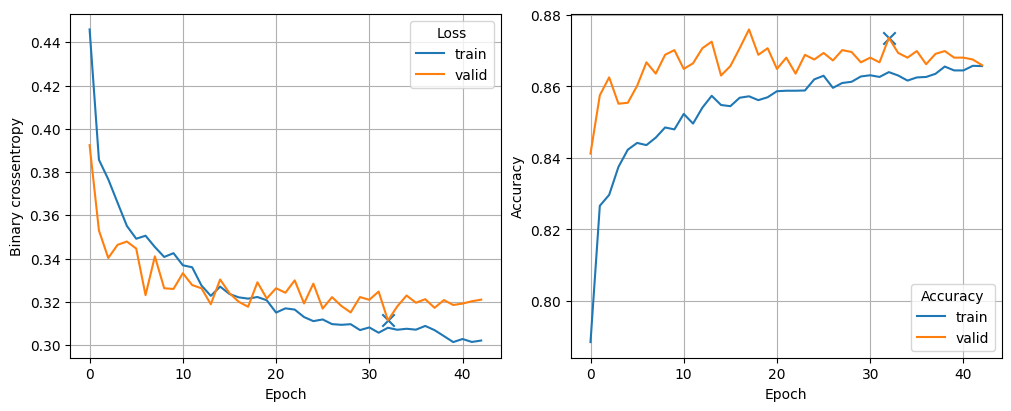

In [27]:
from itertools import product

EPOCHS = 100
INPUT_DIM = X_train_s.shape[1]

search_space = {
	"num_nodes": [16, 32, 64],
	"dropout_prob": [0.0, 0.2],
	"learning_rate": [1e-2, 5e-3, 1e-3],
	"batch_size": [32, 64, 128],
}

best = {"val_loss": np.inf, "cfg": None, "model": None, "history": None}

# Rebuild datasets when batch size changes
for num_nodes, dropout_prob, learning_rate, batch_size in product(
	search_space["num_nodes"],
	search_space["dropout_prob"],
	search_space["learning_rate"],
	search_space["batch_size"],
):
	train_ds = make_dataset(
		X_train_bal, y_train_bal, batch_size=batch_size, shuffle=True
	)
	valid_ds = make_dataset(
		X_valid_s, y_valid.values, batch_size=batch_size, shuffle=False
	)

	model, history = train_model(
		train_ds=train_ds,
		valid_ds=valid_ds,
		input_dim=INPUT_DIM,
		num_nodes=num_nodes,
		dropout_prob=dropout_prob,
		learning_rate=learning_rate,
		epochs=EPOCHS,
	)

	# Evaluate on validation set
	eval_dict = model.evaluate(valid_ds, return_dict=True, verbose=0)
	val_loss = float(eval_dict["loss"])

	if val_loss < best["val_loss"]:
		best = {
			"val_loss": val_loss,
			"cfg": {
				"num_nodes": num_nodes,
				"dropout_prob": dropout_prob,
				"learning_rate": learning_rate,
				"batch_size": batch_size,
			},
			"model": model,
			"history": history,
		}

print("Best configuration:", best["cfg"], "val_loss:", round(best["val_loss"], 5))
plot_history(best["history"])

In [28]:
y_pred = best["model"].predict(X_test_s)
y_pred = (
	(y_pred > 0.5)
	.astype(int)
	.reshape(
		-1,
	)
)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [29]:
print(classification_report(y_test.values, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1338
           1       0.90      0.91      0.90      2466

    accuracy                           0.87      3804
   macro avg       0.86      0.86      0.86      3804
weighted avg       0.87      0.87      0.87      3804

